# Ejercicios Prácticos - Algoritmos avanzados de clasificación

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1. Considere el conjunto de muestras *{X_v1, y_v1}* dado por el siguiente código:


In [22]:
import numpy as np

rng=np.random.default_rng(seed=5)
MatCov = np.array([[6, -3], [-3, 3.5]])
X_v1 = rng.multivariate_normal([0, 0], MatCov, size=150)
radios2 = X_v1[:, 0]**2 + X_v1[:, 1]**2

y_v1 = np.where(radios2 > 1.5, 1, -1)
pos_neg1 = np.logical_and(X_v1[:, 0] < 0, X_v1[:, 1] < 0)
pos_neg2 = np.logical_and(np.logical_and(X_v1[:, 0] > -2.5, X_v1[:, 0] < -1.5),
np.logical_and(X_v1[:, 1] < 2.5, X_v1[:, 1] > 1.25))

y_v1=y_v1.copy()
y_v1[pos_neg1 == True]=-1
y_v1[pos_neg2 == True]=-1

**a)** Entrene una SVM no lineal que ajuste el modelo de manera que ninguna muestra sea mal clasificada.

**b)** ¿Qué parámetros y valores ha usado? ¿por qué cree que esos parámetros han logrado un ajuste sin error?

**c)** Escriba un bloque de código que calcule la cantidad de errores de clasificación que comete el modelo.

In [23]:
# Vamos a copiar esta función de la práctica que nos permite pintar regiones de decisión
# y usaremos en varios ejercicios

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def pintar_regiones_decision_v2(X, y, clasificador, test_idx=None, resolucion=0.02):
    # Configurar los marcadores y el mapa de color
    marcadores = ('s', 'x', 'o', '^', 'v')
    colores = ['red', 'blue', 'lightgreen', 'gray', 'cyan']
    # Asignación de colores a las clases
    cmap = ListedColormap(colores[:len(np.unique(y))])

    # Preparar los márgenes de la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Preparar los valores puntuales de la superficie de decisión y el valor del
    # clasifidor para dichos puntos
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolucion),
                           np.arange(x2_min, x2_max, resolucion))

    # Pasamos la entrada a matriz con dos columnas para calcular la salida del
    # clasificador
    # Ojo, hemos puesto predict para usar la terminología estandar de las
    # bibliotecas que vamos a usar
    Z = clasificador.predict(np.array([xx1.reshape(-1), xx2.reshape(-1)]).T)
    # Convertimos la salida predicha al formato adecuado para pintar la
    # superficie
    Z = Z.reshape(xx1.shape)

    # Pintar el contorno de la superficie de decisión y se rellena también
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Pintar todas las muestras en la superficie de decisión
    for idx, cl in enumerate(np.unique(y)):
         plt.scatter(x=X[y == cl, 0],
                     y=X[y == cl, 1],
                     alpha=0.8,
                     c=colores[idx],
                     marker=marcadores[idx],
                     label=cl,
                     edgecolor='black')

    # Marcar las que son muestras de test
    if test_idx:
        # Dibujar todas las muestras
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0], X_test[:, 1],
                    facecolors='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Conjunto de test')

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


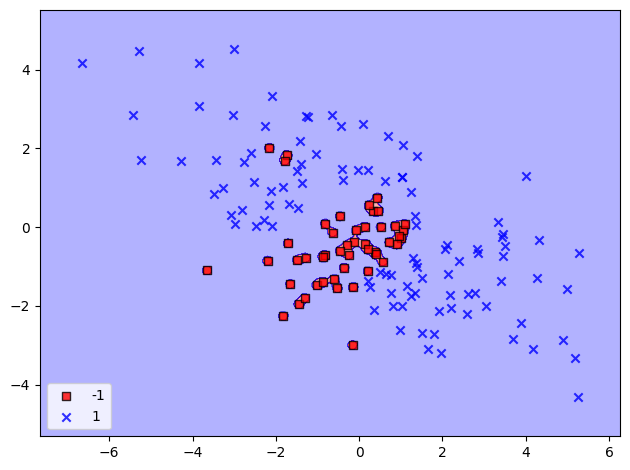

In [24]:
# APARTADO A)

# Importamos de la librería scikit-learn el objeto SVM (Máquina Vector Soporte)
from sklearn.svm import SVC

# Seleccionamos kernel no lineal como se nos indica e indicamos un gamma muy
# grande. Esto, como explicaremos después, nos ayuda a que no haya
# ninguna muestra mal clasificada
svm = SVC(kernel='rbf', random_state=10, gamma=60, C=1.0)

# Entrenamos el SVM no lineal
svm.fit(X_v1, y_v1)
# Pintamos las regiones de decisión (no tenemos subconjunto de test en este caso)
pintar_regiones_decision_v2(X_v1, y_v1, clasificador=svm)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

**APARTADO B)**

He usado $\gamma = 60$, $C = 1$, $\kappa = \exp(-\gamma||x^{(i)}-x^{(j)}||^2)$ y semilla aleatoria $10$. Básicamente, un mayor valor de **gamma** nos produciría un posible sobreajuste de estos datos si tuviéramos un conjunto de test distinto, pero como nos pide un ajuste completamente sin error para los datos de la muestra, eso no nos preocupa.

In [25]:
# APARTADO C)
# Basta calcular las clases predichas una vez entrenada la SVM y compararlas
# con las clases esperadas 'y_v1'
y_pred = svm.predict(X_v1)
print('Cantidad de muestras mal clasificadas: %d de %d' % ((y_v1 != y_pred).sum(), y_v1.shape[0]))

# Es obvio que sale 0, pues estamos haciendo el test con los mismos datos de entrenamiento
# que procuramos que no fueran mal clasificados

Cantidad de muestras mal clasificadas: 0 de 150


2. Cargue el conjunto de muestras Iris completo y divídalo en un 30% para test y un 70% para entrenamiento, que usará en todo el ejercicio.

    **a)** Entrene un árbol de decisión utilizando como rasgos los usados en la práctica guiada, es decir, el ancho del pétalo y el largo del pétalo. Utilice la entropía como criterio. Para clasificar una muestra, el árbol debe hacer el menor número de preguntas y, aunque cometa errores de clasificación, debe ser capaz de distinguir tantas clases de flores como existen en el conjunto de muestras.

    **b)** En el árbol del apartado anterior, ¿cuántas preguntas hay que hacer para clasificar una muestra?

    **c)** ¿Qué modelo cree que está menos ajustado, el que acaba de implementar o uno que tenga profundidad 5? Razone su respuesta.


In [26]:
from sklearn import datasets
import numpy as np

# Cargamos el dataset iris usando directamente la librería skicit-learn
iris = datasets.load_iris()

# Seleccionamos como rasgos el ancho del pétalo ('3') y la longitud del pétalo ('2')
X_completo = iris.data[:, [2, 3]]
y_completo = iris.target
print('Etiquetas de las clases:', np.unique(y_completo))

Etiquetas de las clases: [0 1 2]


In [27]:
from sklearn.model_selection import train_test_split

# Dividimos nuestra muestra en un subconjunto del 70% para entrenamiento y un
# 30% para test posterior. Importante usar 'stratify' para que mantenga también el mismo
# número de cada clase en ambos subconjuntos
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X_completo, y_completo, test_size=0.3,
                                                    random_state=10, stratify=y_completo)

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


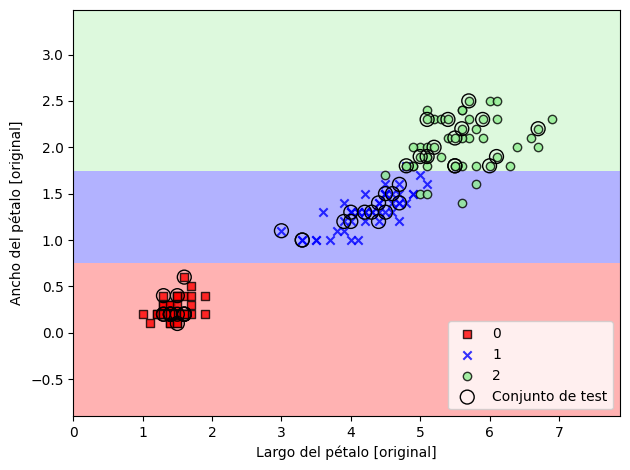

In [28]:
# APARTADO A)
from sklearn.tree import DecisionTreeClassifier

# Entrenamos un árbol de decisión como hemos visto en la práctica
# Usaremos como criterio la entropía y cargaremos como max_depth = 2
# ya que se nos pide que el árbol haga el mínimo número de preguntas
# pero existen tres clases distintas a diferenciar

arbolD = DecisionTreeClassifier(criterion='entropy',
                                    max_depth=2,
                                    random_state=10)
arbolD.fit(X_entrenamiento, y_entrenamiento)
X_entYtest = np.vstack((X_entrenamiento, X_test))
y_entYtest = np.hstack((y_entrenamiento, y_test))
pintar_regiones_decision_v2(X_entYtest,
                      y_entYtest,
                      clasificador=arbolD,
                      test_idx=range(105, 150))
plt.xlabel('Largo del pétalo [original]')
plt.ylabel('Ancho del pétalo [original]')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

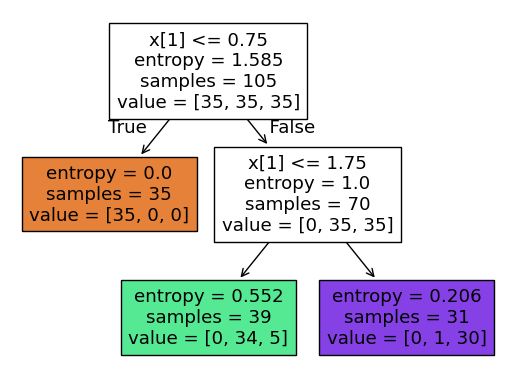

In [29]:
from sklearn import tree

# Dibujamos el árbol de decisión con el que hemos clasificado las anteriores muestras
tree.plot_tree(arbolD, filled = True)
plt.show()

**APARTADO B)**

Como ya hemos comentado en el *apartado a)* y podemos ver en el árbol de decisión, basta realizar como máximo <u>dos preguntas</u> para clasificar una muestra. En este caso, si el ancho del pétalo es menor o mayor que 0.75cm y posteriormente, si es mayor que 1.75 cm o está entre 0.75cm y 1.75cm.

**APARTADO C)**

El modelo con profundidad 5 tiene mucho mayor ajuste que el modelo anterior, de profundidad 2. Esto se debe a que el árbol de decisión es más complejo y puede sobreajustarse a los datos de entrenamiento dados.

3. Considere de nuevo el conjunto de datos *{X_v1, y_v1}* visto en el ejercicio 1. Divida las 150 muestras en un 70% entrenamiento y un 30% test, use semilla aleatoria 5. Use esta división de muestras en todo el ejercicio.

    **a)** Entrene dos árboles de decisión con gini como criterio y semilla aleatoria 5, el árbol A tendrá profundidad máxima de 3 y el B tendrá 6.

    **b)** Dibuje dos gráficas, una para cada árbol, en las que se muestren las regiones de decisión y se diferencien las muestras de entrenamiento y de test.

    **c)** Dibuje los árboles de preguntas de ambos modelos.

    **d)** Dibuje un gráfico de barras apiladas para comparar el rendimiento en test de ambos árboles. En la primera barra dibuje, para el árbol A, la exactitud en test de color verde y de color rojo el error, hago lo mismo en la segunda barra para el
    árbol B.

    **e)** Para saber qué modelo tiene mejor capacidad de generalización, ¿sería necesario conocer el rendimiento en el conjunto entrenamiento?

    **f)** ¿Cuál de los dos árboles generaliza mejor? ¿por qué el otro árbol generaliza peor, diría que tiende al sobreajuste o al subajuste?

In [30]:
# Dividimos nuestra muestra en un subconjunto del 70% para entrenamiento y un
# 30% para test posterior. Importante usar 'stratify' para que mantenga también el mismo
# número de cada clase en ambos subconjuntos y semilla aleatoria 5
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X_v1, y_v1, test_size=0.3,
                                                    random_state=5, stratify=y_completo)

In [31]:
# APARTADO A)

# Entrenamos el árbol de decisión A con el criterio Gini y
# máxima profundidad de 3
arbolA = DecisionTreeClassifier(criterion='gini',
                                    max_depth=3,
                                    random_state=5)
arbolA.fit(X_entrenamiento, y_entrenamiento)

# Entrenamos el árbol de decisión B con el criterio Gini y
# máxima profundidad de 6
arbolB = DecisionTreeClassifier(criterion='gini',
                                    max_depth=6,
                                    random_state=5)
arbolB.fit(X_entrenamiento, y_entrenamiento)

DecisionTreeClassifier(max_depth=6, random_state=5)

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


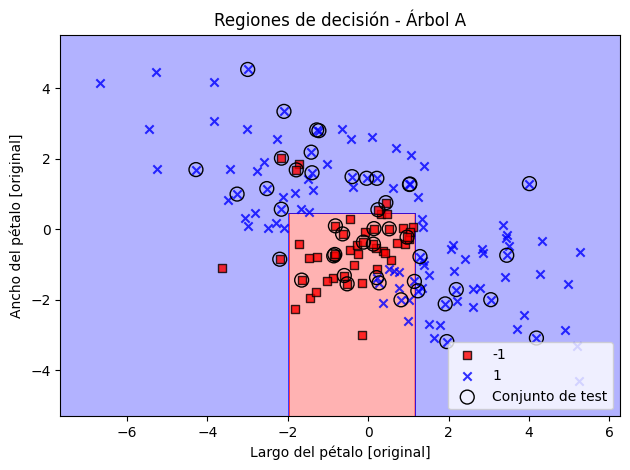

In [32]:
# APARTADO B)
X_entYtest = np.vstack((X_entrenamiento, X_test))
y_entYtest = np.hstack((y_entrenamiento, y_test))

pintar_regiones_decision_v2(X_entYtest,
                      y_entYtest,
                      clasificador=arbolA,
                      test_idx=range(105, 150))
plt.title('Regiones de decisión - Árbol A')
plt.xlabel('Largo del pétalo [original]')
plt.ylabel('Ancho del pétalo [original]')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


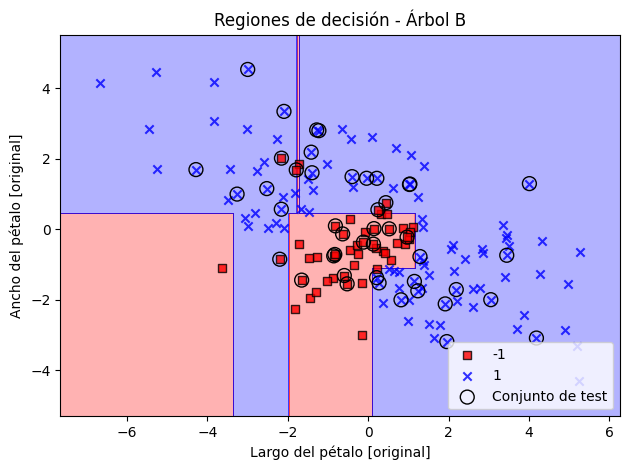

In [33]:
pintar_regiones_decision_v2(X_entYtest,
                      y_entYtest,
                      clasificador=arbolB,
                      test_idx=range(105, 150))
plt.title('Regiones de decisión - Árbol B')
plt.xlabel('Largo del pétalo [original]')
plt.ylabel('Ancho del pétalo [original]')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

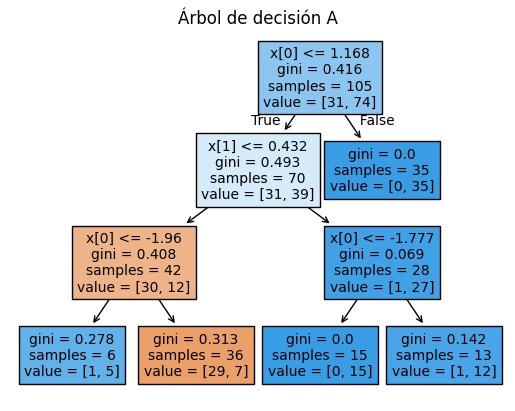

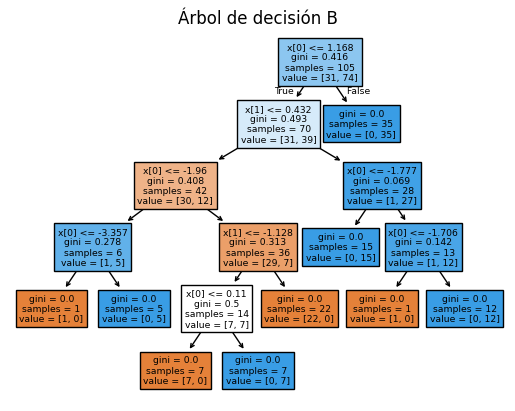

In [34]:
# APARTADO C)

# Dibujamos el árbol de decisión A
tree.plot_tree(arbolA, filled = True)
plt.title('Árbol de decisión A')
plt.show()

# Dibujamos el árbol de decisión B
tree.plot_tree(arbolB, filled = True)
plt.title('Árbol de decisión B')
plt.show()

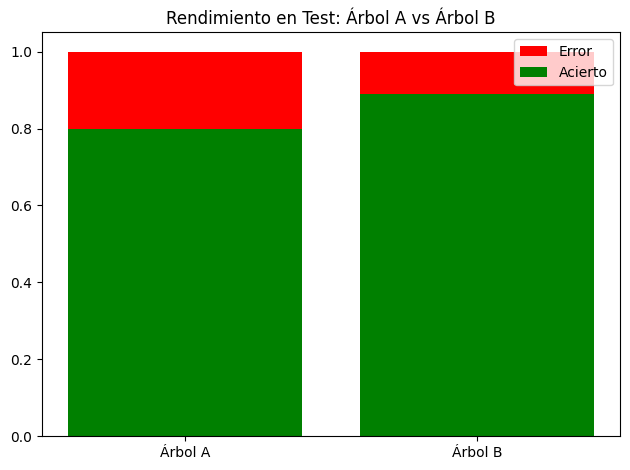

In [35]:
# APARTADO D)

from sklearn.metrics import accuracy_score
import pandas as pd

# Usando la función accuracy_score de skicit-learn calculamos la precisión
# de ambos árboles en nuestro subconjunto de test

acc_A = accuracy_score(y_test, arbolA.predict(X_test))
acc_B = accuracy_score(y_test, arbolB.predict(X_test))

# Cargamos los resultados de Aciertos y Errores en un dataframe

data = pd.DataFrame({
    'Acierto': [acc_A, acc_B],
    'Error': [1 - acc_A, 1 - acc_B]
}, index=['Árbol A', 'Árbol B'])

# Dibujamos el gráfico de barras apiladas como vimos en la práctica guiada
# Generamos primero el gráfico de barras de detrás (rojo) y luego el gráfico
# apilado de los aciertos de cada árbol (verde)

plt.bar(data.index, data.Acierto + data.Error, label='Error', color = "red")
plt.bar(data.index, data.Acierto, label='Acierto', color = "green")

plt.title('Rendimiento en Test: Árbol A vs Árbol B')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**APARTADO E)**

**No necesariamente** para comparar generalización, pero sí para ver porqué sucede. La capacidad de generalización se mide exclusivamente con el subconjunto de test.

Sin embargo, saber el rendimiento en el subconjunto de entrenamiento es importante para explicar porqué falla el modelo. Si la precisión en entrenamiento es mucho mayor que en test, hay sobreajuste. Si ambas son bajas, es que tenemos subajuste.

**APARTADO F)**

Generalmente, el Árbol A de profundidad 3 suele generalizar mejor. Al tener una restricción de profundidad, se ve obligado a aprender los patrones más significativos y descartar detalles mínimos. El árbol B tiende al **sobreajuste** pues memoriza patrones muy particulares que después puede que no se den en el subconjunto de test.

4. Ejecute el siguiente código para generar un conjunto de muestras:



In [36]:
import numpy as np

np.random.seed(15)
X_v4 = np.random.randn(150, 2)

pos_Clase1 = np.logical_and(X_v4[:, 0] > 0, X_v4[:, 1] > 0)
pos_Clase2 = np.logical_and(X_v4[:, 0] < -0.5, X_v4[:, 1] < 0)

y_v4=np.zeros(X_v4.shape[0])
y_v4[pos_Clase1]=1
y_v4[pos_Clase2]=2

Divida las muestras en un 70% para entrenamiento y un 30% para test, úselas en todo el ejercicio.

**a)** Clasifique las muestras mediante los siguientes modelos predictivos vistos en esta unidad: regresión logística (biblioteca scikit-learn y solver=lbfgs), árboles de decisión y KNN. En aras de la simplicidad, cuando cree los modelos, utilice los valores por defecto en los constructores de los objetos.

**b)** Indique cuál es el peor modelo para clasificar estas muestras. Justifique su respuesta utilizando la medida de rendimiento que estime oportuna.

**c)** ¿Por qué el modelo del apartado anterior no se adapta tan bien a las muestras? Apoye su respuesta ilustrándola con las gráficas que crea adecuadas.

In [37]:
# Dividimos nuestra muestra en un subconjunto del 70% para entrenamiento y un
# 30% para test posterior. Importante usar 'stratify' para que mantenga también el mismo
# número de cada clase en ambos subconjuntos y semilla aleatoria 15 por ejemplo

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X_v4, y_v4, test_size=0.3,
                                                    random_state=15, stratify=y_completo)

# En este caso, como vamos a usar clasificadores como KNN o de regresión logística,
# vamos a escalar las muestras debido a que son muy sensibles a las diferentes escalas
# como vimos en la práctica

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_entrenamiento)
X_entrenamiento_std = sc.transform(X_entrenamiento)
X_test_std = sc.transform(X_test)

X_entYtest_std = np.vstack((X_entrenamiento_std, X_test_std))
y_entYtest = np.hstack((y_entrenamiento, y_test))

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


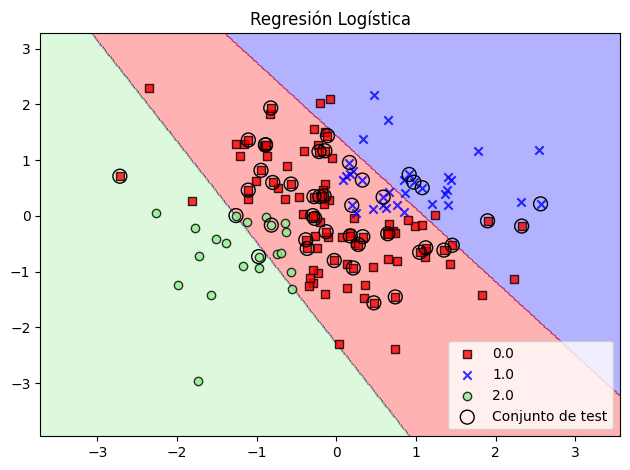

In [38]:
# APARTADO A) - Regresión Logística

from sklearn.linear_model import LogisticRegression

# Usamos el constructor LogisticRegression con solver 'lbfgs' y el resto
# de valores por defecto
neuronaLogistica = LogisticRegression(solver='lbfgs')
neuronaLogistica.fit(X_entrenamiento_std, y_entrenamiento)

pintar_regiones_decision_v2(X_entYtest_std,
                      y_entYtest,
                      clasificador=neuronaLogistica,
                      test_idx=range(105, 150))
plt.title("Regresión Logística")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


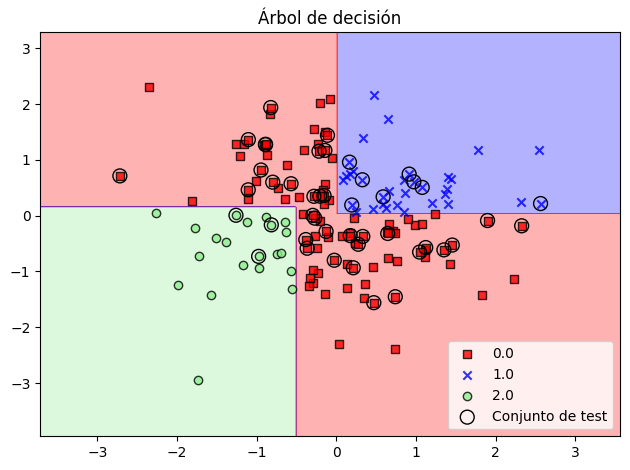

In [39]:
# APARTADO A) - Árbol de decisión

# Creamos el árbol de decisión con los valores por defecto
arbolDec = DecisionTreeClassifier()
arbolDec.fit(X_entrenamiento_std, y_entrenamiento)

pintar_regiones_decision_v2(X_entYtest_std,
                      y_entYtest,
                      clasificador=arbolDec,
                      test_idx=range(105, 150))
plt.title('Árbol de decisión')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2490826572.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


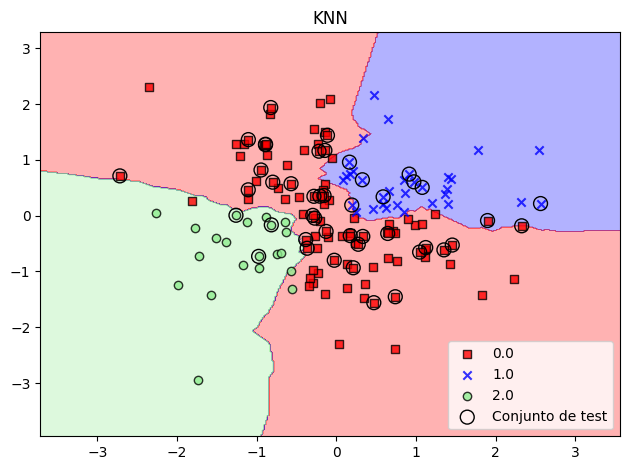

In [40]:
# APARTADO A) - KNN
from sklearn.neighbors import KNeighborsClassifier

# Creamos un objeto KNeighborsClassifier con parámetros por defecto
knn = KNeighborsClassifier()
knn.fit(X_entrenamiento_std, y_entrenamiento)

pintar_regiones_decision_v2(X_entYtest_std,
                      y_entYtest,
                      clasificador=knn,
                      test_idx=range(105, 150))
plt.title('KNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

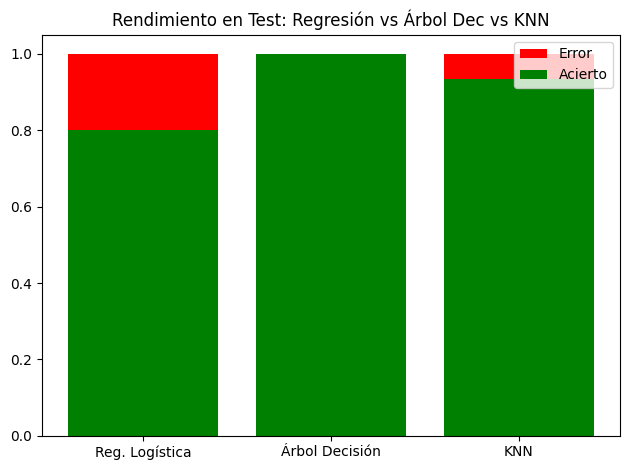

In [41]:
# APARTADO B)

# Usaremos el diagrama de barras apilado para visualizar los errores cometidos
# al clasificar las muestras de test de cada uno

# Usando la función accuracy_score de skicit-learn calculamos la precisión
# de los tres clasificadores en nuestro subconjunto de test

acc_A = accuracy_score(y_test, neuronaLogistica.predict(X_test_std))
acc_B = accuracy_score(y_test, arbolDec.predict(X_test_std))
acc_C = accuracy_score(y_test, knn.predict(X_test_std))

# Cargamos los resultados de Aciertos y Errores en un dataframe

data = pd.DataFrame({
    'Acierto': [acc_A, acc_B, acc_C],
    'Error': [1 - acc_A, 1 - acc_B, 1 - acc_C]
}, index=['Reg. Logística', 'Árbol Decisión', 'KNN'])

# Dibujamos el gráfico de barras apiladas como vimos en la práctica guiada
# Generamos primero el gráfico de barras de detrás (rojo) y luego el gráfico
# apilado de los aciertos de cada árbol (verde)

plt.bar(data.index, data.Acierto + data.Error, label='Error', color = "red")
plt.bar(data.index, data.Acierto, label='Acierto', color = "green")

plt.title('Rendimiento en Test: Regresión vs Árbol Dec vs KNN')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

El peor modelo para clasificación de estas muestras es la <u> Regresión Logística </u> con un 20% de errores en el conjunto de test.

**APARTADO C)**

La razón por la cual la Regresión Logística no se adapta bien es su **naturaleza lineal**. Este modelo intenta separar las clases mediante hiperplanos. Para separar la Clase 1 y la Clase 2 (de la Clase 0, necesitamos fronteras no lineales. Esto se puede ver claramente en el gráfico anteriormente generado de regiones de decisión.

5. Cargue el conjunto de muestras “winequality-red.csv”, puede usar las siguientes etiquetas para los atributos y <u>clase deseada</u>:

    'Acidez', 'Acidez volátil', 'Ácido cítrico', 'Azúcar', 'Cloruros', 'DS libre', 'DS total',
    'Densidad', 'pH', 'Sulfitos', 'Alcohol', '<u>Calidad</u>'

    Divida el conjunto de muestras en un 70% para entrenamiento y un 30% para test, después escale las muestras. Use estas muestras en el resto del ejercicio.

    **a)** ¿Cuántas calidades de vinos hay en el conjunto de muestras? ¿cuál es la calidad mínima? ¿y la máxima?

    **b)** Clasifique las muestras mediante máquinas de vectores de soporte no lineal con *gamma* = 1 y pruebe los siguientes valores de *C* = {10^{−2}, 10^{−1}, 1, 10, 10^2}. En una gráfica con la exactitud en el eje vertical y los valores de *C* en el horizontal, dibuje una curva para la exactitud en el conjunto de test y otra curva para la exactitud en el conjunto de entrenamiento.

    **c)** Dibuje dos diagramas de sectores, cada sector representará la cantidad de muestras que pertenecen a cada clase. En el primer diagrama represente las predicciones en el conjunto de test de una máquina de vectores de soporte no lineal con *gamma* = 1 y *C* = 102, en el segundo diagrama represente las clases deseadas del conjunto de test. En ambos casos dibuje la leyenda, separe el sector más numeroso del resto del diagrama, gire 30º el diagrama y utilice el parámetro `labeldistance=None` en la función pie.

    **d)** ¿Clasifica bien las muestras? Comente los resultados que observa en los diagramas del apartado anterior.



In [42]:
import pandas as pd

df = pd.read_csv('winequality-red.csv', names=['Acidez', 'Acidez volátil', 'Ácido cítrico', 'Azúcar', 'Cloruros', 'DS libre', 'DS total',
    'Densidad', 'pH', 'Sulfitos', 'Alcohol', 'Calidad'])

X_v5 = df.drop('Calidad', axis=1).values
y_v5 = df['Calidad'].values

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X_v5, y_v5,
    test_size=0.3,
    random_state=15,
    stratify=y_v5
)

# Escalado de muestras
sc = StandardScaler()
sc.fit(X_entrenamiento)
X_entrenamiento_std = sc.transform(X_entrenamiento)
X_test_std = sc.transform(X_test)

X_entYtest_std = np.vstack((X_entrenamiento_std, X_test_std))
y_entYtest = np.hstack((y_entrenamiento, y_test))


In [43]:
# APARTADO A)

# Usando las funciones visats en el primer módulo sobre la biblioteca Pandas
# en un dataframe, usamos nunique(), max() y min() para averiguar estos valores

num_calidades = df['Calidad'].nunique()
calidad_min = df['Calidad'].min()
calidad_max = df['Calidad'].max()

# En el archivo NAMES se describe que 'Calidad' es un valor entre 0 y 10 entero
# luego como máximo podría haber 11 valores únicos y tener mínimo 0 y máximo 10

print(f"Número de calidades de vinos: {num_calidades}")
print(f"Calidad mínima: {calidad_min}")
print(f"Calidad máxima: {calidad_max}")

Número de calidades de vinos: 6
Calidad mínima: 3
Calidad máxima: 8


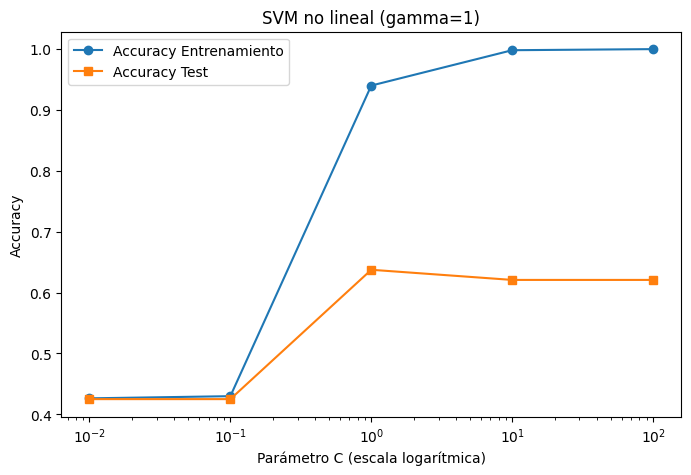

In [44]:
# APARTADO B)

# Iteramos sobre los valores de C y guardamos la accuracy
# con el conjunto de entrenamiento y de test
valores_C = [0.01, 0.1, 1, 10, 100]
train_accuracies = []
test_accuracies = []

for c in valores_C:

    # Configuramos SVM no lineal con gamma=1 y C correspondiente
    svm = SVC(kernel='rbf', gamma=1, C=c, random_state=15)
    svm.fit(X_entrenamiento_std, y_entrenamiento)

    y_train_pred = svm.predict(X_entrenamiento_std)
    y_test_pred = svm.predict(X_test_std)

    # Añadimos a estas listas la precisión correspondiente
    train_accuracies.append(accuracy_score(y_entrenamiento, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))


plt.figure(figsize=(8, 5))
plt.plot(valores_C, train_accuracies, marker='o', label='Accuracy Entrenamiento')
plt.plot(valores_C, test_accuracies, marker='s', label='Accuracy Test')

# Añadimos escala logarítmica para una mejor visualización de resultados
plt.xscale('log')
plt.xlabel('Parámetro C (escala logarítmica)')
plt.ylabel('Accuracy')
plt.title('SVM no lineal (gamma=1)')
plt.legend()
plt.show()

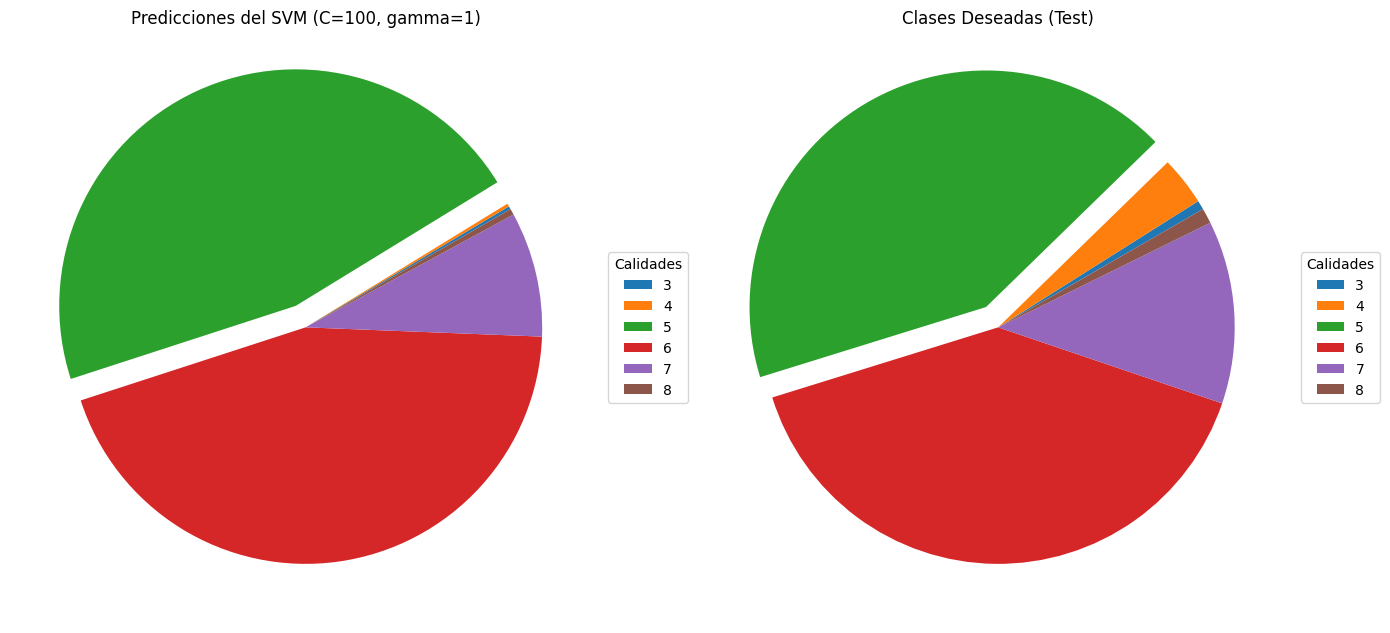

In [45]:
# APARTADO C)

# Generamos el SVM no lineal con gamma = 1 y C = 100
svm_final = SVC(kernel='rbf', gamma=1, C=100, random_state=15)
svm_final.fit(X_entrenamiento_std, y_entrenamiento)
y_pred_test = svm_final.predict(X_test_std)

# Usamos unique para contar el número de elementos por clase predichos
clases_pred, counts_pred = np.unique(y_pred_test, return_counts=True)
clases_real, counts_real = np.unique(y_test, return_counts=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# 'explode' nos permite encontrar el sector más numeroso y separarlo del
# resto del diagrama
explode = [0.1 if v == counts_pred.max() else 0 for v in counts_pred]

ax1.pie(
        counts_pred,
        labels=clases_pred,
        explode=explode,
        startangle=30,  # Giramos 30º
        labeldistance=None,  # Pedido en el enunciado
)
ax1.set_title("Predicciones del SVM (C=100, gamma=1)")
ax1.legend(title="Calidades", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

explode2 = [0.1 if v == counts_real.max() else 0 for v in counts_real]

ax2.pie(
        counts_real,
        labels=clases_real,
        explode=explode2,
        startangle=30,
        labeldistance=None,
)
ax2.set_title("Clases Deseadas (Test)")
ax2.legend(title="Calidades", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

**APARTADO D)**

Es fácil ver que el diagrama de las predicciones realizadas por el SVM casi exclusivamente predice las clases 5, 6 y 7. Es cierto que son las mayoritarias en el diagrama real, pero esto hace que las menos frecuentes, desaparezcan casi totalmente en nuestras predicciones. Luego, no clasifica correctamente las muestras.

Además, al haber tomado un valor de $\gamma = 1$ se produce un sobreajuste como vimos en el apartado anterior al tener un accuracy muy alto en el subconjunto de entrenamiento.

## Ejercicio Avanzado

6. Cargue el conjunto de datos Breast Cancer que viene incorporado en sklearn ejecutando el siguiente código (en “X” estarán los rasgos y en “y” las salidas deseadas):

In [46]:
from sklearn.datasets import load_breast_cancer

data_breast_cancer = load_breast_cancer()
X=data_breast_cancer['data']
y=data_breast_cancer['target']

Haga una división en conjuntos de entrenamiento (70%) y test (30%), que usará en todo el ejercicio.

**a)** Entrene diferentes árboles de decisión, usando el criterio de Gini y el criterio de la entropía. Pruebe con valores del número máximo de nodos hoja (`max_leaf_nodes`) desde 2 hasta 20, ambos inclusive. Mida la exactitud (accuracy) para los conjuntos de entrenamiento y test. Una vez hechas todas estas pruebas, genere una única figura en la que se puedan comparar los resultados obtenidos. El eje horizontal será el número máximo de nodos hoja, y el eje vertical la exactitud. Debe haber cuatro series de datos, según el criterio utilizado y según el conjunto de datos usado (entrenamiento o test).

**b)** ¿El ajuste a los datos de entrenamiento aumenta o disminuye conforme aumenta el valor del número máximo de hojas?

 **c)** ¿Cree que mejora o empeora la capacidad de generalización del modelo al aumentar el valor del número máximo de hojas? Razone sus respuestas.

**d)** Repita el apartado a, pero en este caso variando el parámetro del mínimo número de muestras exigido para dividir un nodo (`min_samples_split`). Pruebe con 80 valores igualmente espaciados de `min_samples_split`, desde 0.01 hasta 1.

**e)** ¿Existe alguna relación entre los resultados obtenidos en los apartados a y d?


In [47]:
# Hacemos la división como hemos venido haciendo en el resto de ejercicios

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=15,
    stratify=y
)

# Como vamos a clasificar por árboles de decisión, no es necesario escalar las muestras

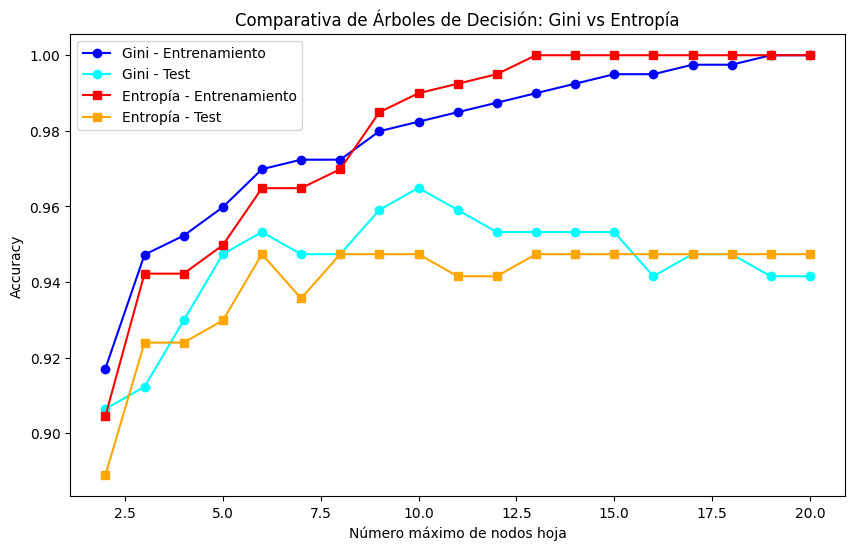

In [48]:
# APARTADO A)

# Iteraremos según criterio y según número de nodos hojas máximos
criterios = ['gini', 'entropy']
nodos_hoja = list(range(2,21))

# Guardaremos los resultados de 'accuracy' por cada criterio y num_hojas
# Separar entre los subconjuntos de entrenamiento y test

resultados = {
    'gini': {'train': [], 'test': []},
    'entropy': {'train': [], 'test': []}
}

for crit in criterios:
    for max_leaf in nodos_hoja:

        # Creamos un árbol de decisión con los parámetros establecidos
        clf = DecisionTreeClassifier(criterion=crit, max_leaf_nodes=max_leaf, random_state=15)
        clf.fit(X_entrenamiento, y_entrenamiento)

        # Calculamos accuracy en test y entrenamiento
        train_acc = accuracy_score(y_entrenamiento, clf.predict(X_entrenamiento))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        resultados[crit]['train'].append(train_acc)
        resultados[crit]['test'].append(test_acc)

# Una vez calculados todas las exactitudes, las pintamos en una única figura
# según criterio y tipo de subconjunto de muestra

plt.figure(figsize=(10, 6))

plt.plot(nodos_hoja, resultados['gini']['train'], label='Gini - Entrenamiento', color='blue', marker='o')
plt.plot(nodos_hoja, resultados['gini']['test'], label='Gini - Test', color='cyan', marker='o')

plt.plot(nodos_hoja, resultados['entropy']['train'], label='Entropía - Entrenamiento', color='red', marker = 's')
plt.plot(nodos_hoja, resultados['entropy']['test'], label='Entropía - Test', color='orange', marker='s')

plt.xlabel('Número máximo de nodos hoja')
plt.ylabel('Accuracy')
plt.title('Comparativa de Árboles de Decisión: Gini vs Entropía')
plt.legend()
plt.show()

**APARTADO B)**

Como vemos en la gráfica anterior, cuanto más nodos hojas máximo permitidos hay, ocurre **más ajuste** de los datos (en los subconjuntos de entrenamiento se llega a una accuracy del 100% con ambos criterios).

**APARTADO C)**

La capacidad de generalización del modelo **empeora** conforme el valor del número máximo de hojas. Es cierto que, al principio, como se produce un subajuste, el aumento de este parámetro nos mejora la precisión del clasificador, pero llega un punto en el que se empieza a producir un sobreajuste de los datos.

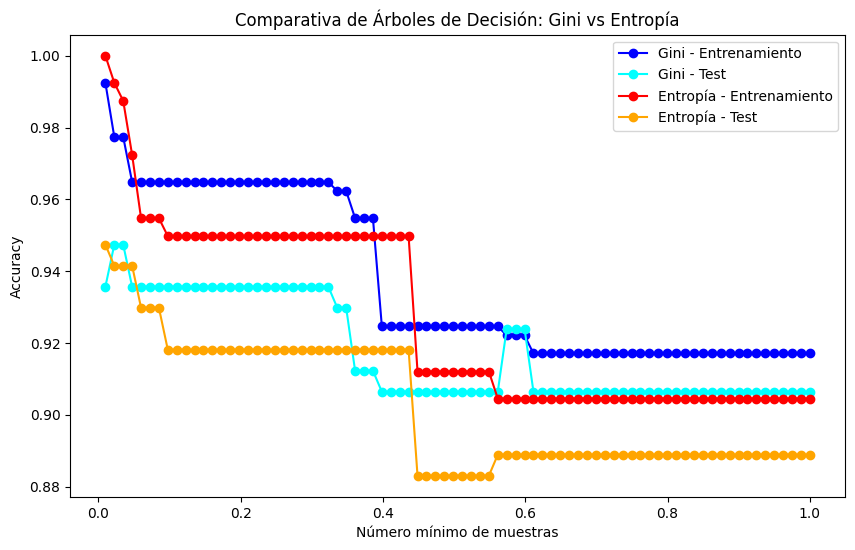

In [49]:
# APARTADO D)

# Iteraremos según criterio y según número de muestras mínimas
criterios = ['gini', 'entropy']
min_muestras = list(np.linspace(0.01,1,80))

# Guardaremos los resultados de 'accuracy' por cada criterio y min_samples
# Separar entre los subconjuntos de entrenamiento y test

resultados = {
    'gini': {'train': [], 'test': []},
    'entropy': {'train': [], 'test': []}
}

for crit in criterios:
    for muestras in min_muestras:

        # Creamos un árbol de decisión con los parámetros establecidos
        clf = DecisionTreeClassifier(criterion=crit, min_samples_split=muestras, random_state=15)
        clf.fit(X_entrenamiento, y_entrenamiento)

        # Calculamos accuracy en test y entrenamiento
        train_acc = accuracy_score(y_entrenamiento, clf.predict(X_entrenamiento))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        resultados[crit]['train'].append(train_acc)
        resultados[crit]['test'].append(test_acc)

# Una vez calculados todas las exactitudes, las pintamos en una única figura
# según criterio y tipo de subconjunto de muestra

plt.figure(figsize=(10, 6))

plt.plot(min_muestras, resultados['gini']['train'], label='Gini - Entrenamiento', color='blue', marker='o')
plt.plot(min_muestras, resultados['gini']['test'], label='Gini - Test', color='cyan', marker='o')

plt.plot(min_muestras, resultados['entropy']['train'], label='Entropía - Entrenamiento', color='red', marker = 'o')
plt.plot(min_muestras, resultados['entropy']['test'], label='Entropía - Test', color='orange', marker='o')

plt.xlabel('Número mínimo de muestras')
plt.ylabel('Accuracy')
plt.title('Comparativa de Árboles de Decisión: Gini vs Entropía')
plt.legend()
plt.show()

**APARTADO E)**

**Sí**, existe una relación inversa entre los parámetros de *min_samples_split* y *max_leafs_nodes*. Ambos parámetros son herramientas de regularización para controlar el crecimiento del árbol, pero actúan al contrario.

- En el apartado **a)**, la complejidad aumenta conforme el valor crece (más nodos implican un árbol más complejo).

- En el apartado **d)**, la complejidad aumenta conforme el valor disminuye (un valor cercano a 0 permite que el árbol se divida casi por cualquier muestra, haciéndolo muy complejo).

## Ejercicio Experto

7. Cargue el conjunto de datos Breast Cancer que viene incorporado en sklearn, como en el ejercicio anterior. Haga una división en conjuntos de entrenamiento (70%) y test (30%), que usará en todo el ejercicio.

    **a)** Entrene diferentes clasificadores de los k vecinos más próximos, usando las
    siguientes métricas: 'braycurtis', 'canberra', 'chebyshev', 'cityblock', 'correlation',
    'cosine', 'euclidean'. Pruebe con valores del número de vecinos más próximos
    (n_neighbors) desde 1 hasta 40, ambos inclusive. Mida la exactitud (accuracy)
    para los conjuntos de entrenamiento y test. Una vez hechas todas estas pruebas,
    genere dos figuras en las que se puedan comparar los resultados obtenidos. Una
    figura mostrará la exactitud en entrenamiento y la otra figura la exactitud en test.
    El eje horizontal será el número de vecinos más próximos, y el eje vertical la
    exactitud. Debe haber siete series de datos en cada figura, según la métrica
    utilizada.

    **b)** ¿El ajuste a los datos de entrenamiento aumenta o disminuye conforme aumenta el valor del número de vecinos (k)?

    **c)** ¿Cree que mejora o empeora la capacidad de generalización del modelo al aumentar el valor del número de vecinos (k)? Razone su respuesta.

    **d)** Mida el tiempo de CPU necesario para realizar el entrenamiento, es decir, lo que
    tarda en ejecutarse el método `fit()`. Mida también el tiempo de CPU necesario
    para realizar la predicción sobre el conjunto de test, es decir, lo que tarda en
    ejecutarse el método `predict()` sobre el conjunto de test. Puede medir los
    tiempos con `time.perf_counter()`. Genere dos gráficas, una para el tiempo
    de CPU de entrenamiento y otra para el tiempo de CPU de test, con el mismo
    formato que las generadas en el apartado a.

    **e)** ¿Cómo evoluciona el tiempo de CPU conforme aumenta el número de vecinos
    más próximos en entrenamiento y test? Razone los posibles motivos.



In [50]:
# Hacemos la división como hemos venido haciendo en el resto de ejercicios

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=15,
    stratify=y
)

# En este caso, es necesario escalar las muestras porque usaremos KNN

sc = StandardScaler()
sc.fit(X_entrenamiento)
X_entrenamiento_std = sc.transform(X_entrenamiento)
X_test_std = sc.transform(X_test)

X_entYtest_std = np.vstack((X_entrenamiento_std, X_test_std))
y_entYtest = np.hstack((y_entrenamiento, y_test))

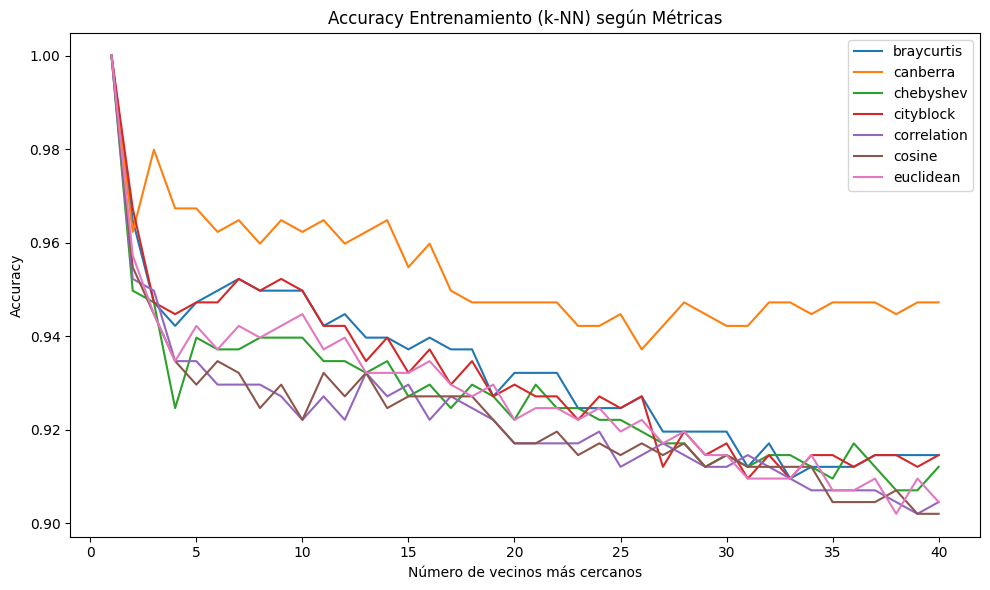

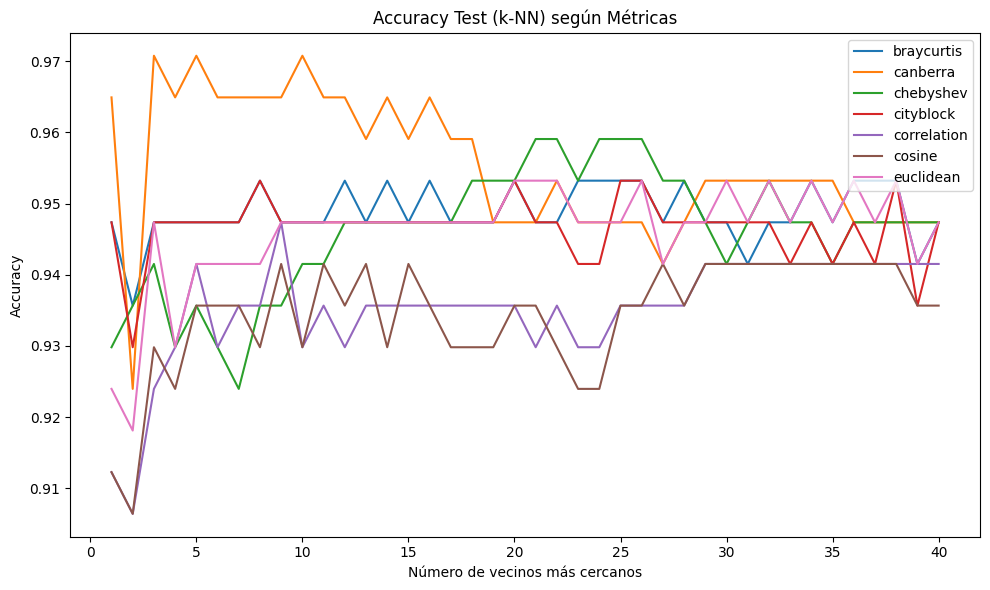

In [51]:
# APARTADO A)

metrics = ['braycurtis', 'canberra', 'chebyshev', 'cityblock', 'correlation',
'cosine', 'euclidean']

num_vecinos = list(range(1,41))

# Guardaremos los resultados de 'accuracy' por cada métrica y numero de vecinos
# Separar entre los subconjuntos de entrenamiento y test

resultados = {
    'braycurtis': {'train': [], 'test': []},
    'canberra': {'train': [], 'test': []},
    'chebyshev': {'train': [], 'test': []},
    'cityblock': {'train': [], 'test': []},
    'correlation': {'train': [], 'test': []},
    'cosine': {'train': [], 'test': []},
    'euclidean': {'train': [], 'test': []}
}

for met in metrics:
    for vecinos in num_vecinos:

        # Creamos KNN con los parámetros establecidos
        knn = KNeighborsClassifier(metric=met, n_neighbors=vecinos)
        knn.fit(X_entrenamiento, y_entrenamiento)

        # Calculamos accuracy en test y entrenamiento
        train_acc = accuracy_score(y_entrenamiento, knn.predict(X_entrenamiento))
        test_acc = accuracy_score(y_test, knn.predict(X_test))

        resultados[met]['train'].append(train_acc)
        resultados[met]['test'].append(test_acc)

# Una vez calculados todas las exactitudes, las pintamos en una única figura
# según criterio y tipo de subconjunto de muestra

plt.figure(figsize=(10, 6))
for met in metrics:
    plt.plot(num_vecinos, resultados[met]['train'], label=met)
plt.title('Accuracy Entrenamiento (k-NN) según Métricas')
plt.xlabel('Número de vecinos más cercanos')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))
for met in metrics:
    plt.plot(num_vecinos, resultados[met]['test'], label=met)
plt.title('Accuracy Test (k-NN) según Métricas')
plt.xlabel('Número de vecinos más cercanos')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**APARTADO B)**

El ajuste a los datos de entrenamiento **disminuye** conforme aumenta el valor del número de vecinos. Esto se visualiza correctamente en la primera gráfica con la mayoría de métricas elegidas en los K-NN.

**APARTADO C)**

La capacidad de generalización del modelo mejora inicialmente hasta alcanzar un momento óptimo y luego empeorará si seguimos aumentando el valor de $k$ (número de vecinos próximos) excesivamente. Como ya hemos visto en el resto de ejercicios, debemos encontrar el punto óptimo entre un subajuste y un sobreajuste de los datos.

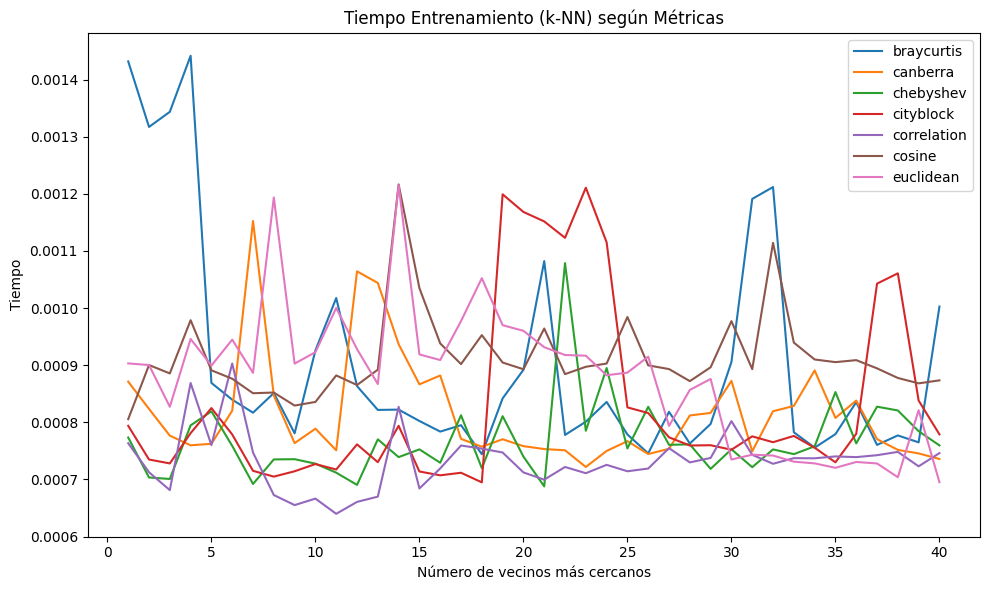

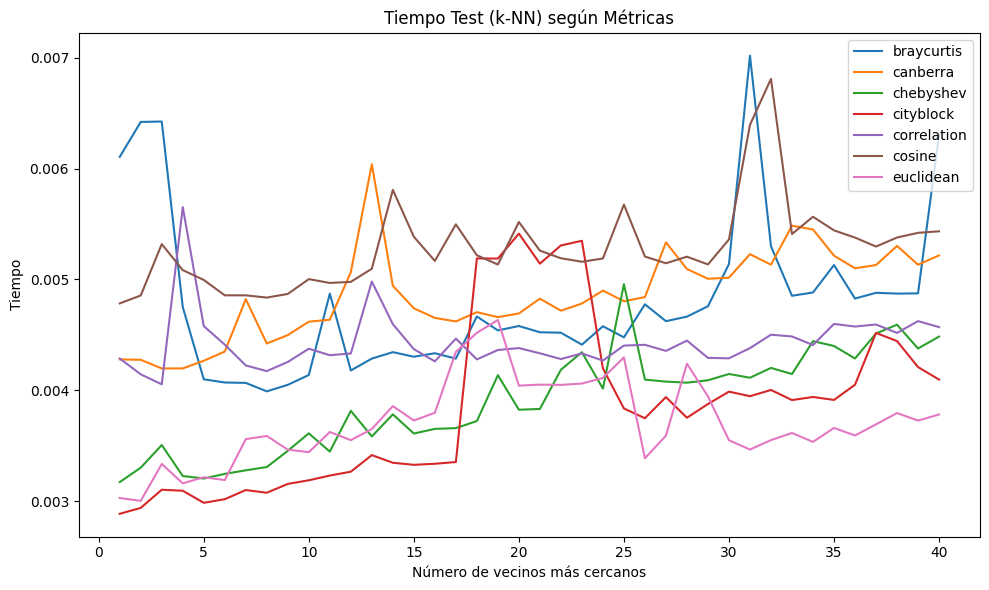

In [52]:
# APARTADO D)

import time

# Inicializamos dos diccionarios que guardarán los tiempos de CPU por métrica
# y número de vecinos

train_times = {m: [] for m in metrics}
test_times = {m: [] for m in metrics}

for met in metrics:
    for vecinos in num_vecinos:

        # Creamos KNN con los parámetros establecidos
        knn = KNeighborsClassifier(metric=met, n_neighbors=vecinos)

        # Calculamos el tiempo necesario para realizar entrenamiento
        t0_fit = time.perf_counter()
        knn.fit(X_entrenamiento, y_entrenamiento)
        t1_fit = time.perf_counter()
        train_times[met].append(t1_fit - t0_fit)

        # Calculamos el tiempo necesario para realizar prediccion
        t0_pred = time.perf_counter()
        knn.predict(X_test)
        t1_pred = time.perf_counter()
        test_times[met].append(t1_pred - t0_pred)

plt.figure(figsize=(10, 6))
for met in metrics:
    plt.plot(num_vecinos, train_times[met], label=met)
plt.title('Tiempo Entrenamiento (k-NN) según Métricas')
plt.xlabel('Número de vecinos más cercanos')
plt.ylabel('Tiempo')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

plt.figure(figsize=(10, 6))
for met in metrics:
    plt.plot(num_vecinos, test_times[met], label=met)
plt.title('Tiempo Test (k-NN) según Métricas')
plt.xlabel('Número de vecinos más cercanos')
plt.ylabel('Tiempo')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

**APARTADO E)**

- Tiempo de entrenamiento ('*fit*'): el tiempo es prácticamente constante y casi nulo, independientemente del valor de $k$. En k-NN, el método fit no construye un modelo. Lo único que hace es almacenar en memoria las muestras de entrenamiento. Como esta operación es simplemente una asignación de datos, el valor de $k$ no influye en esta fase.

- Tiempo de test ('*predict*'): el tiempo es mucho mayor que en el entrenamiento, pero se mantiene relativamente constante o aumenta de forma ligera conforme $k$ crece de 1 a 40. Esto es debido a que se debe hacer un cálculo de distancias y una búsqueda de dichos k vecinos.